In [18]:

import os
import numpy as np
import flopy
import matplotlib.pyplot as plt

# Define the bed elevation for filtering particles
bed_elevation = 1599.8125  # Replace with the actual bed elevation value
ncol = 215
nrow = 192
#\Users\u4eeevmq\Documents\Python\HP_workspace
# Define the workspace and file names
workspace = r"C:\Users\u4eeevmq\Documents\Python\HP_workspace\mp7_workspace"
workspace_gwf = r"C:\Users\u4eeevmq\Documents\Python\HP_workspace\gwf_workspace"

model_name = "Hyporheic_Project_mp"  # Replace with your model name

#     r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_backward.mppth"

# Define the MODPATH 7 pathline and endpoint files
pathline_file = os.path.join(workspace_gwf, model_name + "_forward.mppth")
endpoint_file = os.path.join(workspace_gwf, model_name + "_forward.mpend")


In [34]:
# Read endpoint data
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Filter particles that end at or above the bed elevation
filtered_particles = [ep for ep in endpoints if ep['z'] >= bed_elevation]
filtered_particle_ids = [ep['particleid'] for ep in filtered_particles]

# Convert particle IDs to plain Python integers
filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]

print(f"Converted Particle IDs: {filtered_particle_ids}")

#(k,i,j location)

print(f"Total particles ending at or above bed elevation: {len(filtered_particles)}")
print(f"Particle IDs ending at or above bed elevation: {filtered_particle_ids}")

print("Available fields in endpoint data:", endpoints[0].dtype.names)

# Convert filtered_particle_ids into a list
particle_ids_list = list(filtered_particle_ids)

# Print the resulting list
print(particle_ids_list)


Converted Particle IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,

In [36]:
# Read pathline data only for selected partticles
pathline_reader = flopy.utils.PathlineFile(pathline_file)

# Load pathline data for all particle IDs in the list
filtered_pathlines = []
for particle_id in particle_ids_list:
    filtered_pathlines.extend(pathline_reader.get_data(partid=particle_id))

# Print the total number of pathlines and the particle IDs list
print(f"Total pathlines corresponding to filtered particles: {len(filtered_pathlines)}")
print("Particle IDs List:", particle_ids_list)


Total pathlines corresponding to filtered particles: 35314
Particle IDs List: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package chd...
    loading package oc...
  loading solution package gwf_model...
['gwf_model']


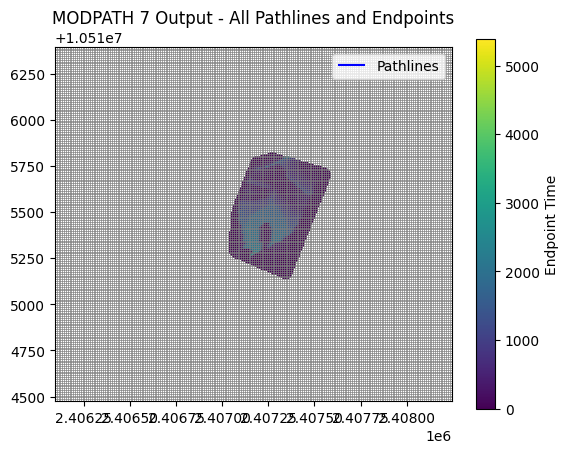

In [33]:
# Plot MODPATH 7 output
# Correct the simulation workspace path
model_ws = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace"

# Load the MODFLOW 6 simulation
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws)
print(sim.model_names)

# Access the groundwater flow (GWF) model
gwf = sim.get_model("gwf_model")  # Replace "gwf" with your model name if different

# Perform further operations
mm = flopy.plot.PlotMapView(model=gwf)

# Plot the grid
mm.plot_grid(lw=0.5)

# Plot all pathlines
mm.plot_pathline(filtered_pathlines, layer="all", colors="blue", label="Pathlines")

# Plot all endpoints
mm.plot_endpoint(endpoints, direction="starting", colorbar=True)

# Add legend
mm.ax.legend()

# Show plot
plt.title("MODPATH 7 Output - All Pathlines and Endpoints")
plt.show()